## 災害データ分析とストーリーテリング

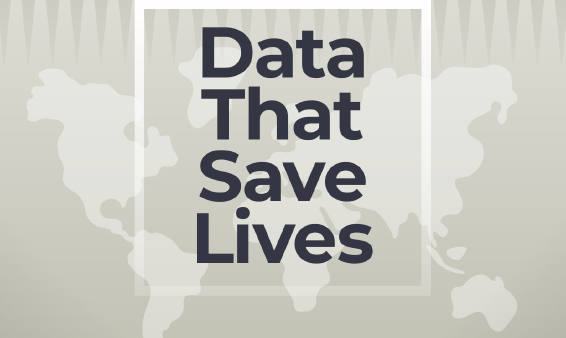
#### **チャレンジの目的**

このチャレンジでは、EM-DAT災害データセットのデータを使ってストーリーを伝える.ipynbファイルを作成します。あなたの独自の視点からデータを分析し、有意義な洞察を導き出し、それを簡潔かつ効果的に視覚的に表現することが目標です。Be creative!

#### **データセットの概要**
https://www.emdat.be/

#### **提出物**

1. **提出物の形式**:
   - Jupyter Notebook (.ipynb) ファイル
   - Markdownセルを使用して、分析の説明、洞察、結論を含むストーリーを伝える。ブログ投稿のように構成すると良いでしょう！
   - コードセルを使用して、データの読み込み、前処理、分析、可視化を行う。
   - Notebook内で生成されたグラフやチャートを含める。
   - 必ず自分のやっていること、感想、学んだことを説明する。

2. **提出方法**:
   - GitHubリポジトリにNotebookをコミットする
   - UNIPAにNotebookのリンクを提出する

3. **締め切り**:
   - 次回のクラス開始前までに提出すること



#### **要件**
1. **フォーカスエリア**:
   - 興味に基づいて**フォーカスエリア**を選択する（例: 災害の種類、死者数、人への影響、地域分析、または時間的トレンド）。

2. **分析**:
   - 計算やデータ探索を通じて、少なくとも**3つの重要な洞察**を提供する。
   - 興味深い統計（種類・地域別の数とか）、トレンド、または異常値を特定する。

3. **可視化**:
   - 分析をサポートする**少なくとも2つの可視化**を作成する。
   - 関連性があり解釈しやすいチャート（例: 棒グラフ、折れ線グラフ、散布図、ヒートマップ）を使用する。

4. **サマリー**:
   - 発見した内容を簡潔にまとめ、その重要性を説明する。



## まずはデータの読み込みから

UNIPAからデータCSVファイルemdata.csvを取得し、このノートブックと同じフォルダに配置してください。次に、以下のコードを実行してデータをpandas DataFrameに読み込みます。



In [2]:
%pip instal matplotlib.pyplot

Note: you may need to restart the kernel to use updated packages.


ERROR: unknown command "instal" - maybe you meant "install"



In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
emdat = pd.read_csv('emdat.csv')

In [4]:
# Explore the data
emdat.head()  # Display the first few rows

,Disaster Subgroup,Disaster Type,Disaster Subtype,ISO,Country,Subregion,Region,Latitude,Longitude,Start Year,Total Deaths
0,Meteorological,Storm,Tropical cyclone,USA,United States of America,Northern America,Americas,NaN,NaN,1900,6000.0
1,Hydrological,Flood,Flood (General),JAM,Jamaica,Latin America and the Caribbean,Americas,NaN,NaN,1900,300.0
2,Biological,Epidemic,Viral disease,JAM,Jamaica,Latin America and the Caribbean,Americas,NaN,NaN,1900,30.0
3,Geophysical,Volcanic activity,Ash fall,JPN,Japan,Eastern Asia,Asia,NaN,NaN,1900,30.0
4,Geophysical,Earthquake,Ground movement,TUR,Türkiye,Western Asia,Asia,40.3,43.1,1900,140.0


## ここからはあなたの分析

以下はあくまでも例：

In [5]:
# Ranking by total deaths
death_ranking = emdat.groupby('Country')['Total Deaths'].sum().sort_values(ascending=False)
print("Top 10 countries by total deaths from disasters:")
print(death_ranking.head(10))

Top 10 countries by total deaths from disasters:
Country
China           12522453.0
India            9138244.0
Soviet Union     3857423.0
Bangladesh       2994475.0
Ethiopia          417252.0
Haiti             253200.0
Indonesia         243370.0
Japan             239761.0
Uganda            207817.0
Niger             196580.0
Name: Total Deaths, dtype: float64


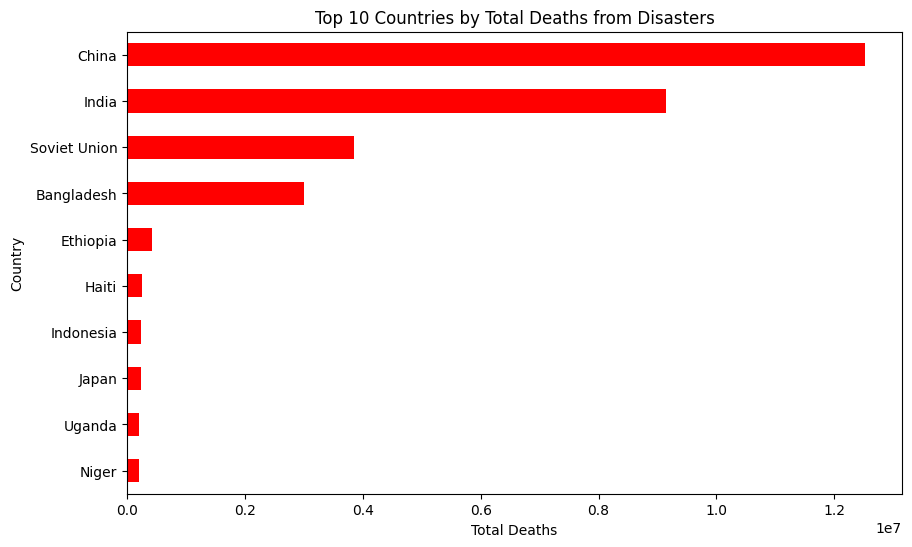

In [6]:
# ranking of total deaths in horizontal bar chart, top 10 countries, highest first 
top_10_deaths = death_ranking.head(10)
plt.figure(figsize=(10, 6))
top_10_deaths.plot(kind='barh', color='red')
plt.xlabel('Total Deaths')
plt.title('Top 10 Countries by Total Deaths from Disasters')
plt.gca().invert_yaxis()  # Highest first
plt.show()

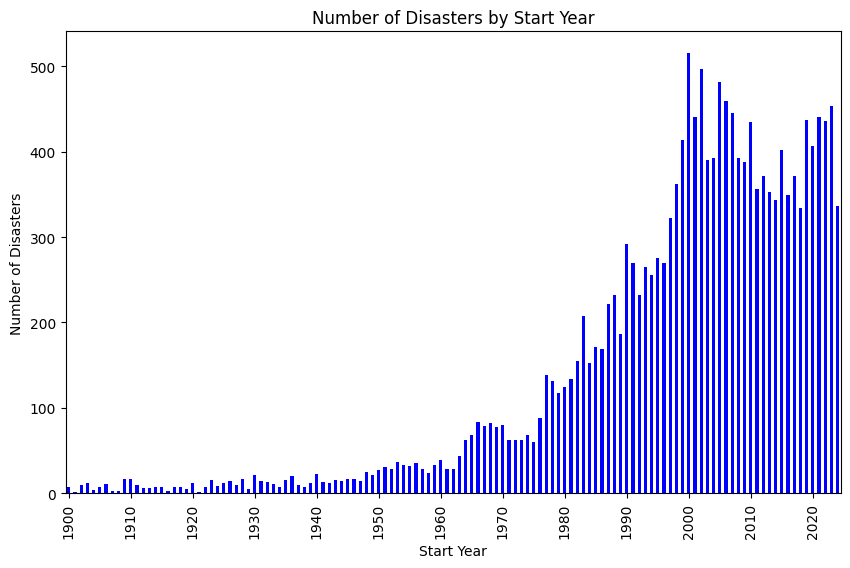

In [7]:
# disasters by year
disasters_by_year = emdat.groupby('Start Year').size()
plt.figure(figsize=(10, 6))
disasters_by_year.plot(kind='bar', color='blue')

# label only every 10 years on x-axis
plt.xticks(ticks=range(0, len(disasters_by_year), 10), labels=disasters_by_year.index[::10])   
plt.xlabel('Start Year')
plt.ylabel('Number of Disasters')
plt.title('Number of Disasters by Start Year')
plt.show()

In [8]:
death_ranking = emdat.groupby('Disaster Type')['Total Deaths'].sum().sort_values(ascending=False)
print("Top 10 countries by total deaths from disasters:")
print(death_ranking.head(10))

Top 10 countries by total deaths from disasters:
Disaster Type
Drought                11734272.0
Epidemic                9623111.0
Flood                   7016630.0
Earthquake              2409975.0
Storm                   1421623.0
Extreme temperature      306324.0
Volcanic activity         86945.0
Mass movement (wet)       69393.0
Wildfire                   5349.0
Mass movement (dry)        4502.0
Name: Total Deaths, dtype: float64


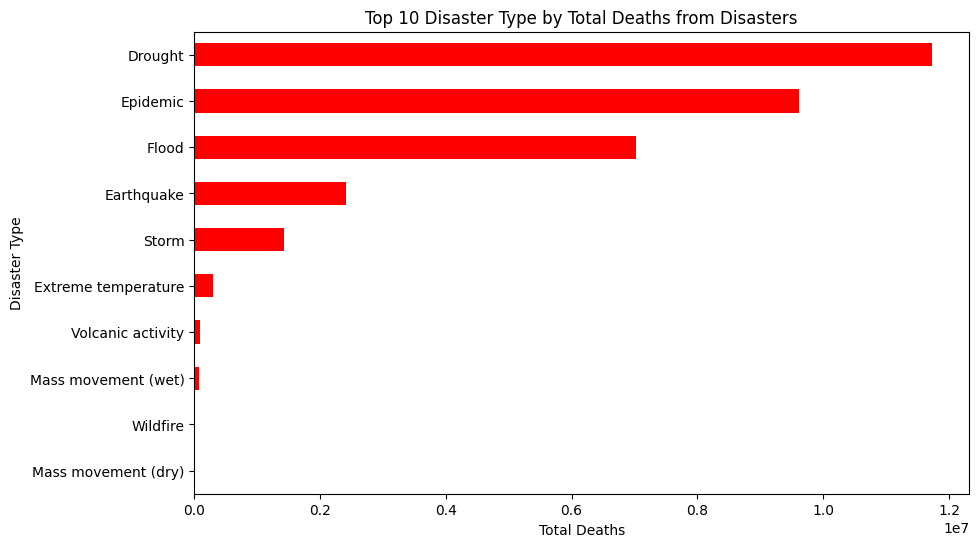

In [9]:
top_10_deaths = death_ranking.head(10)
plt.figure(figsize=(10, 6))
top_10_deaths.plot(kind='barh', color='red')
plt.xlabel('Total Deaths')
plt.title('Top 10 Disaster Type by Total Deaths from Disasters')
plt.gca().invert_yaxis()  # Highest first
plt.show()

## 例にあったものの都市名を災害名に変えてみた
ちょっとしたものだがそれだけでも全然違う見方ができた

In [19]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Yu Gothic'   # Windowsの例


In [20]:
# 日本のデータだけに絞る
japan_data = emdat[emdat['Country'] == 'Japan']

# 災害タイプごとに死亡者数を集計して並べる
japan_ranking = (
    japan_data.groupby('Disaster Type')['Total Deaths']
    .sum()
    .sort_values(ascending=False)
)

print("日本の災害死亡者ランキング：")
print(japan_ranking)


日本の災害死亡者ランキング：
Disaster Type
Earthquake             188415.0
Storm                   34996.0
Flood                   13533.0
Extreme temperature      1128.0
Mass movement (wet)      1110.0
Volcanic activity         578.0
Epidemic                    1.0
Drought                     0.0
Wildfire                    0.0
Name: Total Deaths, dtype: float64


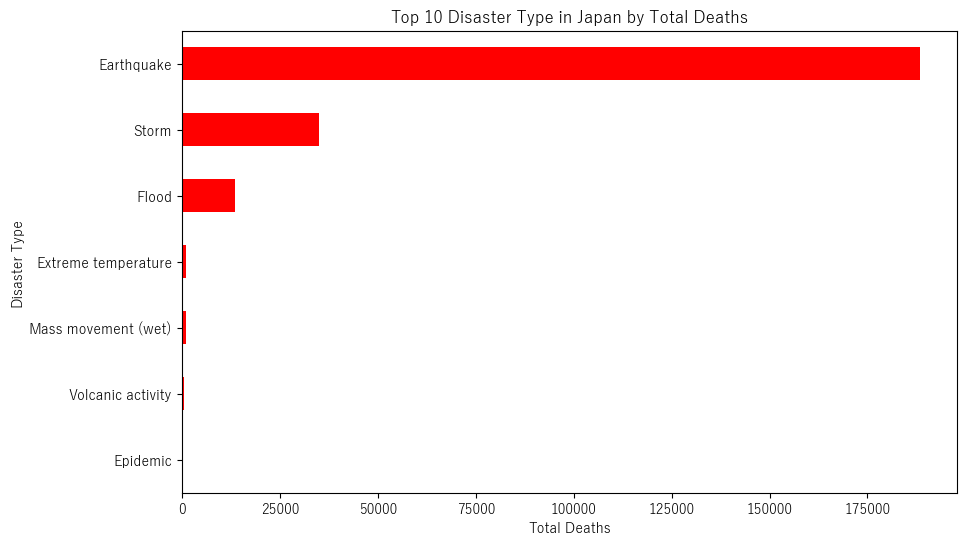

In [23]:
top_10_japan = japan_ranking.head(7)

plt.figure(figsize=(10, 6))
top_10_japan.plot(kind='barh', color='red')
plt.xlabel('Total Deaths')
plt.title('Top 10 Disaster Type in Japan by Total Deaths')
plt.gca().invert_yaxis()  # Highest first
plt.show()

## 前のをさらに変えて形は真似てるが前のよりも自分のやり方を増やしてブラッシュアップしてみた
関数を自分で変えてみたりした

In [4]:
%pip install folium

Defaulting to user installation because normal site-packages is not writeable

   ----------------------------------------  0/10 [xyzservices]
   ---- -----------------------------------  1/10 [urllib3]
   ---- -----------------------------------  1/10 [urllib3]
   ---- -----------------------------------  1/10 [urllib3]
   ---- -----------------------------------  1/10 [urllib3]
   ---- -----------------------------------  1/10 [urllib3]
   ---- -----------------------------------  1/10 [urllib3]
   ---- -----------------------------------  1/10 [urllib3]
   ---- -----------------------------------  1/10 [urllib3]
   -------- -------------------------------  2/10 [MarkupSafe]
   ------------ ---------------------------  3/10 [idna]
   ------------ ---------------------------  3/10 [idna]
   ---------------- -----------------------  4/10 [charset_normalizer]
   ---------------- -----------------------  4/10 [charset_normalizer]
   ---------------- -----------------------  4/10 [charset


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\jitia\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [28]:
import folium
import pandas as pd

# データ読み込み
emdat = pd.read_csv('emdat.csv')

# 日本のデータを抽出
japan = emdat[emdat['Country'] == 'Japan']

# 不要な欠損値を除去
japan = japan.dropna(subset=['Latitude', 'Longitude', 'Total Deaths'])

# 数値変換
japan['Latitude'] = pd.to_numeric(japan['Latitude'], errors='coerce')
japan['Longitude'] = pd.to_numeric(japan['Longitude'], errors='coerce')
japan['Total Deaths'] = pd.to_numeric(japan['Total Deaths'], errors='coerce')

# 再度欠損を除外
japan = japan.dropna(subset=['Latitude', 'Longitude', 'Total Deaths'])

# folium 地図作成（attribution を追加）
m = folium.Map(
    location=[35, 137],
    zoom_start=5,
    tiles='Stamen Toner',
    attr='Map tiles by Stamen Design, under CC BY 3.0. Data by OpenStreetMap, under ODbL.'
)

# 円プロット
for _, row in japan.iterrows():

    # 元の半径計算
    raw_radius = (row['Total Deaths'] ** 0.5) * 2

    # 半径に上限50、下限3を設定
    radius_value = min(max(raw_radius, 3), 50)

    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=radius_value,
        color='red',
        fill=True,
        fill_opacity=0.4,
        popup=f"{row['Disaster Type']} ({int(row['Total Deaths'])})"
    ).add_to(m)

# 地図表示
m


災害での死者は様々な要因があったが日本では地震、台風、洪水の順で高く世界とはかなりランキングが変わっていた。
理由としては日本の気候と災害対策などがあげられる。